# SaaS Product Analytics & Churn Prediction

## 06 — Churn Analysis

### Objective

Analyze customer churn across the SaaS platform and identify behavioral, subscription, product, and revenue patterns associated with customer loss.

This notebook focuses on descriptive and diagnostic churn analysis.

### Areas Covered

- Customer churn rate
- Subscription churn
- Churn by plan
- Churn by billing cycle
- Churn by acquisition source
- Churn by customer tenure
- Churn by engagement
- Churn by product activity
- Churn by revenue segment
- Churn timing
- Churned customer characteristics
- Retained vs churned customer comparison

### Important Distinction

This notebook answers:

> What does churn look like and what characteristics are associated with it?

The next notebook answers:

> Can we predict which customers are likely to churn?

The existing `business_questions.md` file remains the master source for the project's business questions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project Configuration

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
ANALYTICS_DIR = PROJECT_ROOT / "data" / "analytics"

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction


## 2. Load Required Datasets

Churn analysis combines multiple perspectives:

### Users
Provides customer attributes.

### Events
Provides product engagement and activity.

### Subscriptions
Provides plan, billing, revenue, status, and subscription lifecycle information.

### Existing Analytics
Previously generated retention and revenue outputs provide additional analytical context.

In [3]:
def load_dataset(filename):
    processed_path = PROCESSED_DATA_DIR / filename
    raw_path = RAW_DATA_DIR / filename

    if processed_path.exists():
        return pd.read_csv(processed_path)

    if raw_path.exists():
        return pd.read_csv(raw_path)

    raise FileNotFoundError(
        f"Could not find dataset: {filename}"
    )


users = load_dataset("users.csv")
events = load_dataset("events.csv")
subscriptions = load_dataset("subscriptions.csv")

print(f"Users: {len(users):,}")
print(f"Events: {len(events):,}")
print(f"Subscriptions: {len(subscriptions):,}")

Users: 30,000
Events: 1,552,178
Subscriptions: 30,000


## 3. Inspect Subscription Status

Subscription status is the primary source for identifying customers who have cancelled their subscription.

Before calculating churn, we inspect the actual values rather than assuming a particular status naming convention.

In [4]:
print("Subscription columns:")
print(subscriptions.columns.tolist())

print("\nSubscription status distribution:")

if "status" in subscriptions.columns:
    display(
        subscriptions["status"]
        .value_counts(dropna=False)
        .rename_axis("status")
        .reset_index(name="subscriptions")
    )
else:
    print("Status column not found.")

Subscription columns:
['subscription_id', 'user_id', 'company_id', 'plan', 'subscription_start_date', 'subscription_end_date', 'billing_frequency', 'monthly_recurring_revenue', 'annual_contract_value', 'trial', 'status', 'acquisition_source', 'upgrade_count', 'downgrade_count', 'tenure_days']

Subscription status distribution:


,status,subscriptions
0,Active,15159
1,Free,11993
2,Churned,2848


## 4. Standardize Subscription Dates

The project datasets use:

- `subscription_start_date`
- `subscription_end_date`

These dates will be used to determine customer lifecycle and churn timing.

In [5]:
date_columns = [
    "subscription_start_date",
    "subscription_end_date",
]

for column in date_columns:

    if column in subscriptions.columns:

        subscriptions[column] = pd.to_datetime(
            subscriptions[column],
            errors="coerce",
        )

print(
    subscriptions[
        [
            column
            for column in date_columns
            if column in subscriptions.columns
        ]
    ].dtypes
)

subscription_start_date    datetime64[us]
subscription_end_date      datetime64[us]
dtype: object


## 5. Identify Churned Subscriptions

We first inspect status values and then create a standardized churn indicator.

The indicator will be:

- `1` → churned/cancelled
- `0` → not churned

The exact status values are derived from the dataset.

In [6]:
if "status" not in subscriptions.columns:
    raise ValueError(
        "Subscription status column is required."
    )

subscriptions["status_normalized"] = (
    subscriptions["status"]
    .astype(str)
    .str.strip()
    .str.lower()
)

print(
    subscriptions[
        "status_normalized"
    ].value_counts()
)

status_normalized
active     15159
free       11993
churned     2848
Name: count, dtype: int64


In [7]:
churn_status_keywords = {
    "cancelled",
    "canceled",
    "churned",
    "inactive",
    "terminated",
}

subscriptions["is_churned"] = (
    subscriptions["status_normalized"]
    .isin(churn_status_keywords)
    .astype(int)
)

print(
    "Churned subscriptions:",
    subscriptions["is_churned"].sum()
)

print(
    "Non-churned subscriptions:",
    (
        subscriptions["is_churned"] == 0
    ).sum()
)

Churned subscriptions: 2848
Non-churned subscriptions: 27152


## 6. Overall Churn Rate

The overall subscription churn rate is calculated as:

**Churn Rate = Churned Subscriptions / Total Subscriptions**

This provides the first high-level view of customer loss.

In [8]:
total_subscriptions = len(subscriptions)

churned_subscriptions = (
    subscriptions["is_churned"].sum()
)

overall_churn_rate = (
    churned_subscriptions
    / total_subscriptions
    * 100
)

print(
    f"Total subscriptions: "
    f"{total_subscriptions:,}"
)

print(
    f"Churned subscriptions: "
    f"{churned_subscriptions:,}"
)

print(
    f"Overall churn rate: "
    f"{overall_churn_rate:.2f}%"
)

Total subscriptions: 30,000
Churned subscriptions: 2,848
Overall churn rate: 9.49%


## 7. Churn by Plan

Different plans can have significantly different customer economics and retention characteristics.

We compare churn across:

- Free
- Starter
- Professional
- Enterprise

or whatever plan categories are actually present in the dataset.

In [9]:
if "plan" in subscriptions.columns:

    churn_by_plan = (
        subscriptions
        .groupby("plan")
        .agg(
            subscriptions=(
                "subscription_id",
                "nunique",
            ),
            churned_subscriptions=(
                "is_churned",
                "sum",
            ),
        )
        .reset_index()
    )

    churn_by_plan["churn_rate"] = (
        churn_by_plan[
            "churned_subscriptions"
        ]
        /
        churn_by_plan[
            "subscriptions"
        ]
        * 100
    )

    churn_by_plan = (
        churn_by_plan
        .sort_values(
            "churn_rate",
            ascending=False,
        )
    )

    display(
        churn_by_plan
    )

,plan,subscriptions,churned_subscriptions,churn_rate
3,Starter,8316,1634,19.65
2,Professional,7271,956,13.15
0,Enterprise,2420,258,10.66
1,Free,11993,0,0.00


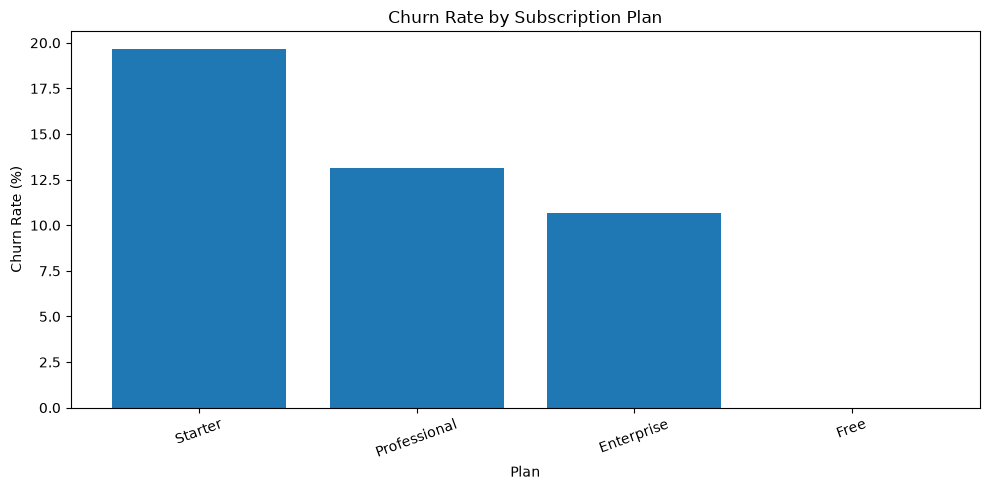

In [10]:
if "plan" in subscriptions.columns:

    plt.figure(
        figsize=(10, 5)
    )

    plt.bar(
        churn_by_plan["plan"],
        churn_by_plan["churn_rate"],
    )

    plt.title(
        "Churn Rate by Subscription Plan"
    )

    plt.xlabel(
        "Plan"
    )

    plt.ylabel(
        "Churn Rate (%)"
    )

    plt.xticks(
        rotation=20
    )

    plt.tight_layout()

    plt.show()

## 8. Churn by Billing Cycle

Billing frequency may influence customer commitment.

We compare churn between different billing cycles such as:

- Monthly
- Annual

In [11]:
billing_column = None

for column in [
    "billing_frequency",
    "billing_cycle",
]:

    if column in subscriptions.columns:
        billing_column = column
        break


if billing_column:

    churn_by_billing = (
        subscriptions
        .groupby(billing_column)
        .agg(
            subscriptions=(
                "subscription_id",
                "nunique",
            ),
            churned_subscriptions=(
                "is_churned",
                "sum",
            ),
        )
        .reset_index()
    )

    churn_by_billing["churn_rate"] = (
        churn_by_billing[
            "churned_subscriptions"
        ]
        /
        churn_by_billing[
            "subscriptions"
        ]
        * 100
    )

    display(
        churn_by_billing
    )

,billing_frequency,subscriptions,churned_subscriptions,churn_rate
0,Annual,3931,626,15.92
1,Monthly,14076,2222,15.79


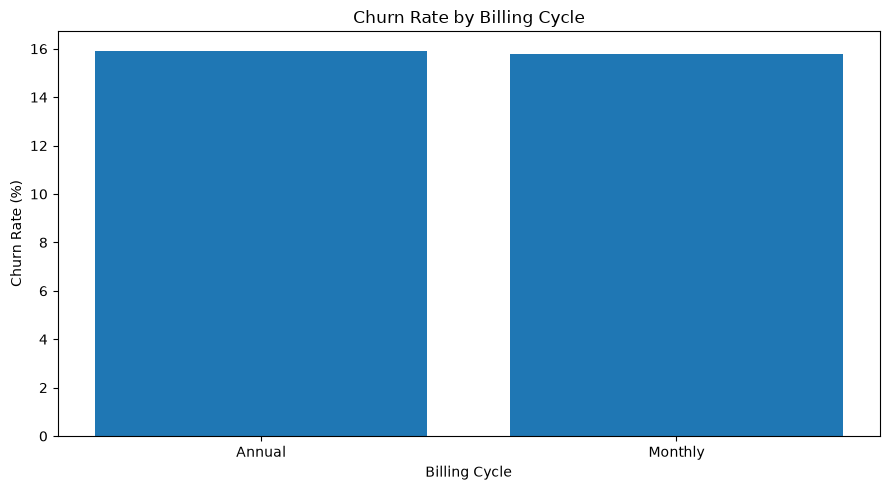

In [12]:
if billing_column:

    plt.figure(
        figsize=(9, 5)
    )

    plt.bar(
        churn_by_billing[
            billing_column
        ].astype(str),
        churn_by_billing[
            "churn_rate"
        ],
    )

    plt.title(
        "Churn Rate by Billing Cycle"
    )

    plt.xlabel(
        "Billing Cycle"
    )

    plt.ylabel(
        "Churn Rate (%)"
    )

    plt.tight_layout()

    plt.show()

## 9. Churn by Acquisition Source

Acquisition source can influence customer quality.

Customers acquired through different channels may demonstrate different:

- Product fit
- Engagement
- Conversion behavior
- Retention
- Revenue potential

We therefore compare churn by acquisition source.

In [13]:
if "acquisition_source" in subscriptions.columns:

    churn_by_source = (
        subscriptions
        .groupby("acquisition_source")
        .agg(
            subscriptions=(
                "subscription_id",
                "nunique",
            ),
            churned_subscriptions=(
                "is_churned",
                "sum",
            ),
        )
        .reset_index()
    )

    churn_by_source["churn_rate"] = (
        churn_by_source[
            "churned_subscriptions"
        ]
        /
        churn_by_source[
            "subscriptions"
        ]
        * 100
    )

    churn_by_source = (
        churn_by_source
        .sort_values(
            "churn_rate",
            ascending=False,
        )
    )

    display(
        churn_by_source
    )

,acquisition_source,subscriptions,churned_subscriptions,churn_rate
0,Partner,1862,311,16.70
1,Sales-Assisted,4893,789,16.13
2,Self-Serve,23245,1748,7.52


## 10. Customer Tenure and Churn

Tenure measures how long a customer remained subscribed.

We calculate:

- Tenure in days
- Tenure in months
- Average tenure of churned customers
- Average tenure of retained customers

This helps identify whether churn is concentrated among newer or more mature customers.

In [14]:
if "tenure_days" in subscriptions.columns:

    subscriptions["tenure_days"] = pd.to_numeric(
        subscriptions["tenure_days"],
        errors="coerce",
    )

else:

    if {
        "subscription_start_date",
        "subscription_end_date",
    }.issubset(
        subscriptions.columns
    ):

        subscriptions["tenure_days"] = (
            subscriptions[
                "subscription_end_date"
            ]
            -
            subscriptions[
                "subscription_start_date"
            ]
        ).dt.days

    else:

        subscriptions["tenure_days"] = np.nan


subscriptions["tenure_months"] = (
    subscriptions["tenure_days"] / 30.44
)

display(
    subscriptions[
        [
            "user_id",
            "tenure_days",
            "tenure_months",
            "is_churned",
        ]
    ].head()
)

,user_id,tenure_days,tenure_months,is_churned
0,U017525,941,30.91,0
1,U017339,941,30.91,0
2,U005513,941,30.91,0
3,U011214,941,30.91,0
4,U001408,941,30.91,0


In [15]:
tenure_summary = (
    subscriptions
    .groupby("is_churned")
    .agg(
        customers=(
            "user_id",
            "nunique",
        ),
        average_tenure_months=(
            "tenure_months",
            "mean",
        ),
        median_tenure_months=(
            "tenure_months",
            "median",
        ),
    )
    .reset_index()
)

tenure_summary["customer_status"] = (
    tenure_summary["is_churned"]
    .map(
        {
            0: "Retained",
            1: "Churned",
        }
    )
)

display(
    tenure_summary[
        [
            "customer_status",
            "customers",
            "average_tenure_months",
            "median_tenure_months",
        ]
    ]
)

,customer_status,customers,average_tenure_months,median_tenure_months
0,Retained,27152,15.61,15.60
1,Churned,2848,6.41,5.65


## 11. Churn by Tenure Segment

Customers are divided into lifecycle segments:

- 0–3 months
- 3–6 months
- 6–12 months
- 12+ months

This helps identify the point in the customer lifecycle where churn risk is highest.

In [16]:
subscriptions["tenure_segment"] = pd.cut(
    subscriptions["tenure_months"],
    bins=[
        -np.inf,
        3,
        6,
        12,
        np.inf,
    ],
    labels=[
        "0-3 Months",
        "3-6 Months",
        "6-12 Months",
        "12+ Months",
    ],
)

churn_by_tenure = (
    subscriptions
    .groupby(
        "tenure_segment",
        observed=False,
    )
    .agg(
        subscriptions=(
            "subscription_id",
            "nunique",
        ),
        churned_subscriptions=(
            "is_churned",
            "sum",
        ),
    )
    .reset_index()
)

churn_by_tenure["churn_rate"] = (
    churn_by_tenure[
        "churned_subscriptions"
    ]
    /
    churn_by_tenure[
        "subscriptions"
    ]
    * 100
)

display(
    churn_by_tenure
)

,tenure_segment,subscriptions,churned_subscriptions,churn_rate
0,0-3 Months,2692,560,20.80
1,3-6 Months,3671,959,26.12
2,6-12 Months,6621,1071,16.18
3,12+ Months,17016,258,1.52


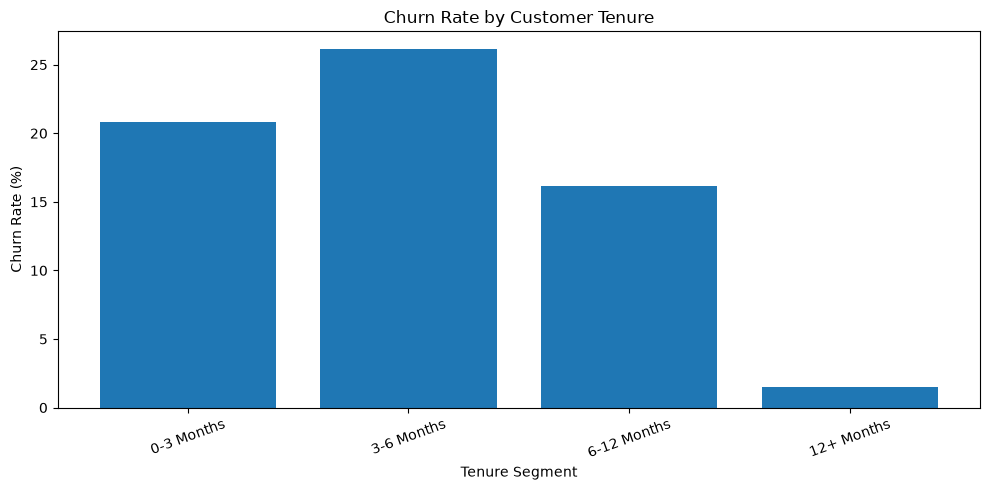

In [17]:
plt.figure(
    figsize=(10, 5)
)

plt.bar(
    churn_by_tenure[
        "tenure_segment"
    ].astype(str),
    churn_by_tenure[
        "churn_rate"
    ],
)

plt.title(
    "Churn Rate by Customer Tenure"
)

plt.xlabel(
    "Tenure Segment"
)

plt.ylabel(
    "Churn Rate (%)"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

## 12. Prepare Event Activity

Customer engagement is one of the most important behavioral dimensions of churn.

We therefore calculate customer-level activity metrics from the event data.

Metrics include:

- Total events
- Active days
- Active months
- First activity
- Last activity
- Recency

In [18]:
event_date_column = None

for column in [
    "event_date",
    "date",
    "timestamp",
    "event_timestamp",
    "created_at",
]:

    if column in events.columns:
        event_date_column = column
        break


if event_date_column is None:
    raise ValueError(
        "Could not identify event date column."
    )


events[event_date_column] = pd.to_datetime(
    events[event_date_column],
    errors="coerce",
)

events["event_date_clean"] = (
    events[event_date_column]
    .dt.normalize()
)

events["event_month"] = (
    events["event_date_clean"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(
    "Event date:",
    events["event_date_clean"].min(),
    "to",
    events["event_date_clean"].max()
)

Event date: 2024-01-05 00:00:00 to 2026-07-31 00:00:00


In [19]:
analysis_end_date = events[
    "event_date_clean"
].max()

user_activity = (
    events
    .groupby("user_id")
    .agg(
        total_events=(
            event_date_column,
            "size",
        ),
        active_days=(
            "event_date_clean",
            "nunique",
        ),
        active_months=(
            "event_month",
            "nunique",
        ),
        first_activity=(
            "event_date_clean",
            "min",
        ),
        last_activity=(
            "event_date_clean",
            "max",
        ),
    )
    .reset_index()
)

user_activity["activity_recency_days"] = (
    analysis_end_date
    - user_activity["last_activity"]
).dt.days

display(
    user_activity.head()
)

,user_id,total_events,active_days,active_months,first_activity,last_activity,activity_recency_days
0,U000001,44,42,18,2024-09-13,2026-07-31,0
1,U000002,36,34,18,2024-03-10,2026-07-31,0
2,U000003,51,44,9,2025-11-15,2026-07-31,0
3,U000004,42,37,17,2024-09-14,2026-07-31,0
4,U000005,70,60,11,2025-09-05,2026-07-31,0


## 13. Combine Subscription and Product Activity

We now create a customer-level analytical dataset.

This dataset combines:

### Subscription behavior

- Plan
- Revenue
- Billing cycle
- Tenure
- Churn

### Product behavior

- Events
- Active days
- Active months
- Recency

This customer-level dataset will become particularly important for the next machine-learning stage.

In [20]:
customer_churn = (
    subscriptions
    .merge(
        user_activity,
        on="user_id",
        how="left",
    )
)

print(
    f"Customer churn dataset: "
    f"{len(customer_churn):,} rows"
)

display(
    customer_churn.head()
)

Customer churn dataset: 30,000 rows


,subscription_id,user_id,company_id,plan,subscription_start_date,subscription_end_date,billing_frequency,monthly_recurring_revenue,annual_contract_value,trial,status,acquisition_source,upgrade_count,downgrade_count,tenure_days,status_normalized,is_churned,tenure_months,tenure_segment,total_events,active_days,active_months,first_activity,last_activity,activity_recency_days
0,SUB0000056,U017525,C02244,Starter,2024-01-02,NaT,Monthly,29.00,348.00,True,Active,Partner,0,0,941,active,0,30.91,12+ Months,49,40,21,2024-02-24,2026-07-31,0
1,SUB0000010,U017339,C04434,Free,2024-01-02,NaT,NaN,0.00,0.00,True,Free,Self-Serve,0,0,941,free,0,30.91,12+ Months,50,44,19,2024-02-03,2026-07-31,0
2,SUB0000007,U005513,C05004,Free,2024-01-02,NaT,NaN,0.00,0.00,True,Free,Self-Serve,0,0,941,free,0,30.91,12+ Months,36,31,21,2024-03-14,2026-07-31,0
3,SUB0000001,U011214,C05116,Free,2024-01-02,NaT,NaN,0.00,0.00,True,Free,Self-Serve,0,0,941,free,0,30.91,12+ Months,50,42,23,2024-02-08,2026-07-31,0
4,SUB0000018,U001408,C06792,Free,2024-01-02,NaT,NaN,0.00,0.00,True,Free,Self-Serve,0,0,941,free,0,30.91,12+ Months,41,36,20,2024-01-06,2026-07-31,0


## 14. Missing Activity Analysis

Not every subscribed customer necessarily generates measurable product events.

We examine customers without recorded activity.

This can reveal:

- Poor onboarding
- Inactive customers
- Data quality issues
- Customers who subscribed but never adopted the product

In [21]:
customer_churn["has_activity"] = (
    customer_churn["total_events"]
    .fillna(0)
    > 0
).astype(int)

activity_status = (
    customer_churn
    .groupby(
        [
            "is_churned",
            "has_activity",
        ]
    )
    .size()
    .reset_index(
        name="customers"
    )
)

activity_status[
    "customer_status"
] = (
    activity_status["is_churned"]
    .map(
        {
            0: "Retained",
            1: "Churned",
        }
    )
)

activity_status[
    "activity_status"
] = (
    activity_status["has_activity"]
    .map(
        {
            0: "No Recorded Activity",
            1: "Active",
        }
    )
)

display(
    activity_status[
        [
            "customer_status",
            "activity_status",
            "customers",
        ]
    ]
)

,customer_status,activity_status,customers
0,Retained,Active,27152
1,Churned,Active,2848


## 15. Engagement Comparison

We compare engagement metrics between retained and churned customers.

Key metrics:

- Total events
- Active days
- Active months
- Activity recency

This helps identify behavioral differences associated with churn.

In [22]:
engagement_summary = (
    customer_churn
    .groupby("is_churned")
    .agg(
        customers=(
            "user_id",
            "nunique",
        ),
        average_events=(
            "total_events",
            "mean",
        ),
        median_events=(
            "total_events",
            "median",
        ),
        average_active_days=(
            "active_days",
            "mean",
        ),
        average_active_months=(
            "active_months",
            "mean",
        ),
        average_recency_days=(
            "activity_recency_days",
            "mean",
        ),
    )
    .reset_index()
)

engagement_summary[
    "customer_status"
] = (
    engagement_summary[
        "is_churned"
    ]
    .map(
        {
            0: "Retained",
            1: "Churned",
        }
    )
)

display(
    engagement_summary[
        [
            "customer_status",
            "customers",
            "average_events",
            "median_events",
            "average_active_days",
            "average_active_months",
            "average_recency_days",
        ]
    ]
)

,customer_status,customers,average_events,median_events,average_active_days,average_active_months,average_recency_days
0,Retained,27152,51.30,50.00,43.05,13.58,0.48
1,Churned,2848,55.91,55.00,47.19,14.47,0.17


## 16. Engagement Distribution

Average values alone can hide major differences.

We therefore examine the distribution of product activity between churned and retained customers.

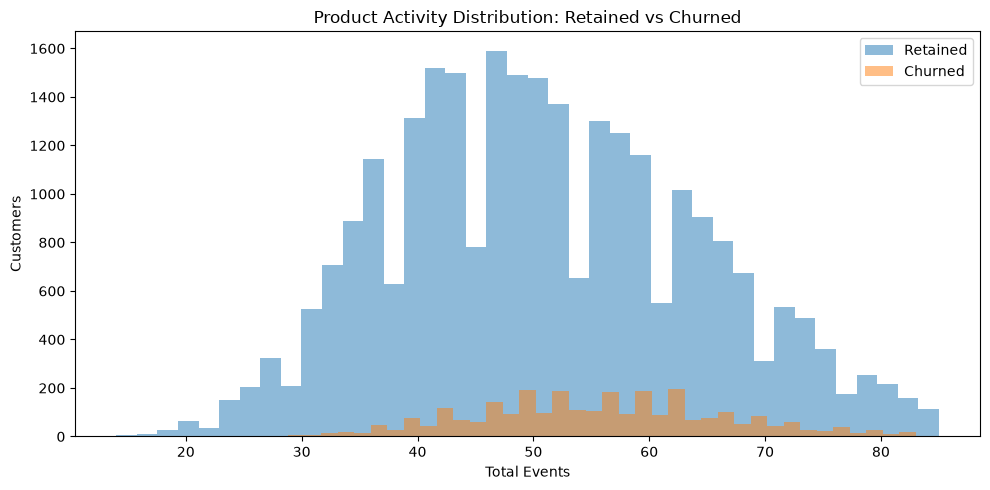

In [23]:
plt.figure(
    figsize=(10, 5)
)

for status, label in [
    (0, "Retained"),
    (1, "Churned"),
]:

    data = customer_churn.loc[
        customer_churn["is_churned"] == status,
        "total_events",
    ].dropna()

    data = data[
        data <= data.quantile(0.99)
    ]

    plt.hist(
        data,
        bins=40,
        alpha=0.5,
        label=label,
    )

plt.title(
    "Product Activity Distribution: Retained vs Churned"
)

plt.xlabel(
    "Total Events"
)

plt.ylabel(
    "Customers"
)

plt.legend()

plt.tight_layout()

plt.show()

## 17. Activity Recency and Churn

Recency is especially important in SaaS.

A customer who has not used the product recently may be at greater risk of cancellation.

We compare the distribution of activity recency for churned and retained customers.

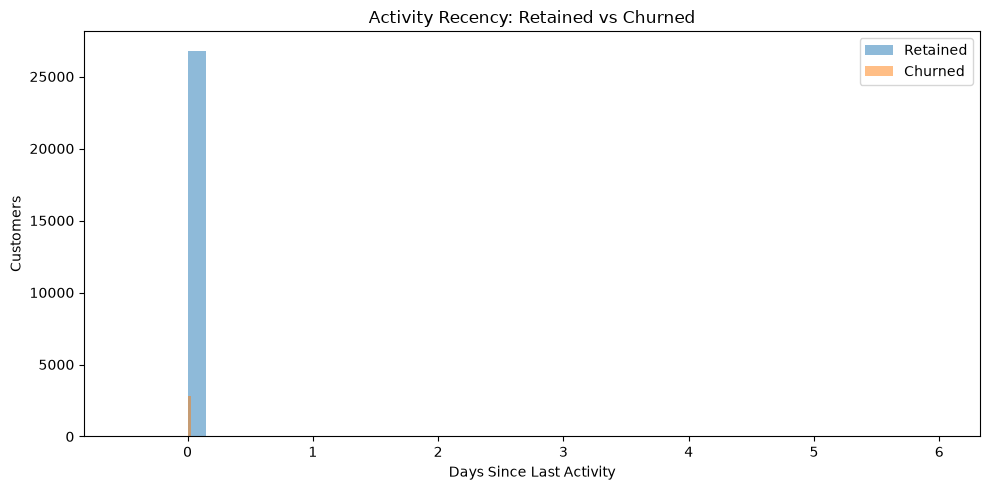

In [24]:
plt.figure(
    figsize=(10, 5)
)

for status, label in [
    (0, "Retained"),
    (1, "Churned"),
]:

    data = customer_churn.loc[
        customer_churn["is_churned"] == status,
        "activity_recency_days",
    ].dropna()

    data = data[
        data <= data.quantile(0.99)
    ]

    plt.hist(
        data,
        bins=40,
        alpha=0.5,
        label=label,
    )

plt.title(
    "Activity Recency: Retained vs Churned"
)

plt.xlabel(
    "Days Since Last Activity"
)

plt.ylabel(
    "Customers"
)

plt.legend()

plt.tight_layout()

plt.show()

## 18. Revenue and Churn

Revenue creates another important perspective.

A business should distinguish between:

- Number of customers lost
- Revenue lost

Losing a large number of low-value customers may have a smaller financial impact than losing a small number of high-value customers.

In [25]:
revenue_column = None

for column in [
    "monthly_recurring_revenue",
    "monthly_revenue",
    "price",
    "mrr",
]:

    if column in customer_churn.columns:
        revenue_column = column
        break


if revenue_column:

    revenue_churn_summary = (
        customer_churn
        .groupby("is_churned")
        .agg(
            customers=(
                "user_id",
                "nunique",
            ),
            total_monthly_revenue=(
                revenue_column,
                "sum",
            ),
            average_monthly_revenue=(
                revenue_column,
                "mean",
            ),
            median_monthly_revenue=(
                revenue_column,
                "median",
            ),
        )
        .reset_index()
    )

    revenue_churn_summary[
        "customer_status"
    ] = (
        revenue_churn_summary[
            "is_churned"
        ]
        .map(
            {
                0: "Retained",
                1: "Churned",
            }
        )
    )

    display(
        revenue_churn_summary[
            [
                "customer_status",
                "customers",
                "total_monthly_revenue",
                "average_monthly_revenue",
                "median_monthly_revenue",
            ]
        ]
    )

,customer_status,customers,total_monthly_revenue,average_monthly_revenue,median_monthly_revenue
0,Retained,27152,"1,122,901.00",41.36,29.00
1,Churned,2848,"174,252.00",61.18,29.00


## 19. Revenue Churn Impact

We estimate the share of recurring revenue associated with churned subscriptions.

This is different from customer churn rate.

### Customer Churn

Percentage of customers lost.

### Revenue Churn

Percentage of recurring revenue associated with churned customers.

The distinction is important for SaaS financial planning.

In [26]:
if revenue_column:

    total_revenue = (
        customer_churn[
            revenue_column
        ]
        .fillna(0)
        .sum()
    )

    churned_revenue = (
        customer_churn.loc[
            customer_churn[
                "is_churned"
            ] == 1,
            revenue_column,
        ]
        .fillna(0)
        .sum()
    )

    revenue_churn_rate = (
        churned_revenue
        / total_revenue
        * 100
        if total_revenue > 0
        else np.nan
    )

    print(
        f"Total recurring revenue: "
        f"${total_revenue:,.2f}"
    )

    print(
        f"Churned recurring revenue: "
        f"${churned_revenue:,.2f}"
    )

    print(
        f"Revenue churn proxy: "
        f"{revenue_churn_rate:.2f}%"
    )

Total recurring revenue: $1,297,153.00
Churned recurring revenue: $174,252.00
Revenue churn proxy: 13.43%


## 20. Churn by Revenue Segment

Customers are divided into revenue segments.

This helps answer:

> Is churn concentrated among low-value customers, mid-value customers, or high-value customers?

In [27]:
if revenue_column:

    customer_churn["revenue_segment"] = pd.qcut(
        customer_churn[
            revenue_column
        ]
        .rank(method="first"),
        q=4,
        labels=[
            "Low Revenue",
            "Lower-Mid Revenue",
            "Upper-Mid Revenue",
            "High Revenue",
        ],
    )

    churn_by_revenue = (
        customer_churn
        .groupby(
            "revenue_segment",
            observed=False,
        )
        .agg(
            customers=(
                "user_id",
                "nunique",
            ),
            churned_customers=(
                "is_churned",
                "sum",
            ),
        )
        .reset_index()
    )

    churn_by_revenue[
        "churn_rate"
    ] = (
        churn_by_revenue[
            "churned_customers"
        ]
        /
        churn_by_revenue[
            "customers"
        ]
        * 100
    )

    display(
        churn_by_revenue
    )

,revenue_segment,customers,churned_customers,churn_rate
0,Low Revenue,7500,0,0.00
1,Lower-Mid Revenue,7500,622,8.29
2,Upper-Mid Revenue,7500,1326,17.68
3,High Revenue,7500,900,12.00


## 21. Churn Timing

For churned customers, we examine when cancellation occurred.

This helps identify:

- Early churn
- Mid-lifecycle churn
- Long-term churn

In [28]:
if "subscription_end_date" in subscriptions.columns:

    churned = subscriptions[
        subscriptions[
            "is_churned"
        ] == 1
    ].copy()

    churned["churn_month"] = (
        churned[
            "subscription_end_date"
        ]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    churn_timing = (
        churned
        .groupby(
            "churn_month"
        )
        .size()
        .reset_index(
            name="churned_subscriptions"
        )
        .sort_values(
            "churn_month"
        )
    )

    display(
        churn_timing
    )

,churn_month,churned_subscriptions
0,2024-03-01,6
1,2024-04-01,8
2,2024-05-01,28
3,2024-06-01,48
4,2024-07-01,54
5,2024-08-01,69
6,2024-09-01,76
7,2024-10-01,61
8,2024-11-01,74
9,2024-12-01,70


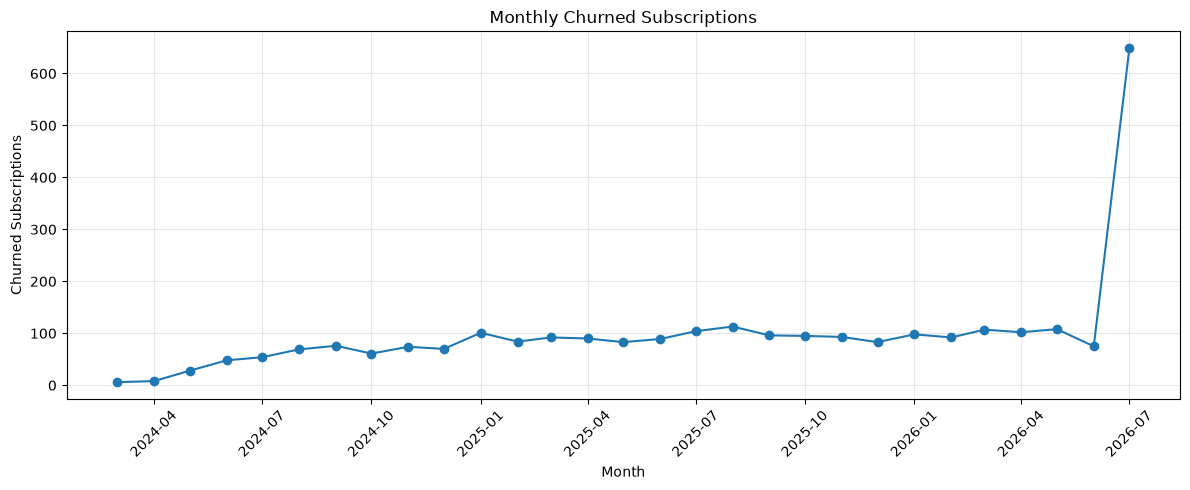

In [29]:
if "churn_timing" in locals():

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        churn_timing[
            "churn_month"
        ],
        churn_timing[
            "churned_subscriptions"
        ],
        marker="o",
    )

    plt.title(
        "Monthly Churned Subscriptions"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Churned Subscriptions"
    )

    plt.xticks(
        rotation=45
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

## 22. Retained vs Churned Customer Profile

We now create an executive comparison between retained and churned customers.

This provides a compact view of behavioral differences.

In [30]:
profile_columns = [
    "total_events",
    "active_days",
    "active_months",
    "activity_recency_days",
    "tenure_months",
]

available_profile_columns = [
    column
    for column in profile_columns
    if column in customer_churn.columns
]

customer_profile = (
    customer_churn
    .groupby("is_churned")[
        available_profile_columns
    ]
    .median()
    .T
)

customer_profile.columns = [
    "Retained",
    "Churned",
]

display(
    customer_profile
)

,Retained,Churned
total_events,50.00,55.00
active_days,42.00,47.00
active_months,14.00,15.00
activity_recency_days,0.00,0.00
tenure_months,15.60,5.65


## 23. Behavioral Churn Indicators

Based on the descriptive analysis, the following variables are especially useful candidates for the predictive modeling stage:

### Engagement

- Total events
- Active days
- Active months

### Recency

- Days since last activity

### Customer lifecycle

- Tenure
- Subscription age

### Commercial

- Plan
- Billing cycle
- Monthly recurring revenue
- Acquisition source

These variables will be evaluated more rigorously in `07_Churn_Prediction.ipynb`.

No predictive conclusion should be made from this descriptive analysis alone.

## 24. Churn Analysis Business Questions

This notebook contributes to the existing business-question framework in `business_questions.md`.

The analysis supports questions around:

- Overall customer churn
- Churn by plan
- Churn by billing cycle
- Churn by acquisition source
- Churn by customer tenure
- Churn by engagement level
- Churn by revenue segment
- Churn timing
- Revenue impact of churn
- Retained versus churned customer behavior
- Product activity associated with customer loss

The master `business_questions.md` file should remain unchanged unless additional questions are intentionally added to the project scope.

## 25. Executive Interpretation Framework

### Customer Churn

The overall churn rate provides the baseline measure of customer loss.

### Product Engagement

Lower activity and higher activity recency among churned customers may indicate weaker product adoption.

### Tenure

If churn is concentrated among newer customers, onboarding and early product adoption may require attention.

### Plan

Differences across plans may indicate different customer-value or product-fit dynamics.

### Billing Cycle

Differences between monthly and annual billing may indicate different levels of customer commitment.

### Revenue Impact

Customer churn and revenue churn should be evaluated separately.

### Acquisition Quality

Significant differences by acquisition source may indicate that some acquisition channels produce customers with stronger long-term fit.

### Strategic Implication

Churn should not be treated as a single metric.

A strong churn strategy combines:

**Customer behavior + product engagement + subscription economics + lifecycle stage.**

## 26. Save Churn Analytics

The generated datasets will be used by:

- `07_Churn_Prediction.ipynb`
- Streamlit application
- `insight.md`
- Executive reporting

In [32]:
ANALYTICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

customer_churn.to_csv(
    ANALYTICS_DIR
    / "customer_churn_analysis.csv",
    index=False,
)

if "churn_by_plan" in locals():
    churn_by_plan.to_csv(
        ANALYTICS_DIR
        / "churn_by_plan.csv",
        index=False,
    )

if "churn_by_billing" in locals():
    churn_by_billing.to_csv(
        ANALYTICS_DIR
        / "churn_by_billing.csv",
        index=False,
    )

if "churn_by_source" in locals():
    churn_by_source.to_csv(
        ANALYTICS_DIR
        / "churn_by_acquisition_source.csv",
        index=False,
    )

churn_by_tenure.to_csv(
    ANALYTICS_DIR
    / "churn_by_tenure.csv",
    index=False,
)

engagement_summary.to_csv(
    ANALYTICS_DIR
    / "churn_engagement_summary.csv",
    index=False,
)

if "revenue_churn_summary" in locals():
    revenue_churn_summary.to_csv(
        ANALYTICS_DIR
        / "churn_revenue_summary.csv",
        index=False,
    )

if "churn_by_revenue" in locals():
    churn_by_revenue.to_csv(
        ANALYTICS_DIR
        / "churn_by_revenue_segment.csv",
        index=False,
    )

print(
    "Churn analytics outputs saved successfully."
)

Churn analytics outputs saved successfully.


## 27. Final Churn Summary

In [33]:
print("=" * 70)
print("SAAS CHURN ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 70)

print(
    f"Total subscriptions: "
    f"{total_subscriptions:,}"
)

print(
    f"Churned subscriptions: "
    f"{churned_subscriptions:,}"
)

print(
    f"Overall churn rate: "
    f"{overall_churn_rate:.2f}%"
)

if "total_events" in customer_churn.columns:

    print(
        f"Median events — retained: "
        f"{customer_churn.loc[customer_churn['is_churned'] == 0, 'total_events'].median():,.0f}"
    )

    print(
        f"Median events — churned: "
        f"{customer_churn.loc[customer_churn['is_churned'] == 1, 'total_events'].median():,.0f}"
    )

if "activity_recency_days" in customer_churn.columns:

    print(
        f"Median recency — retained: "
        f"{customer_churn.loc[customer_churn['is_churned'] == 0, 'activity_recency_days'].median():,.0f} days"
    )

    print(
        f"Median recency — churned: "
        f"{customer_churn.loc[customer_churn['is_churned'] == 1, 'activity_recency_days'].median():,.0f} days"
    )

print("=" * 70)

SAAS CHURN ANALYSIS — EXECUTIVE SUMMARY
Total subscriptions: 30,000
Churned subscriptions: 2,848
Overall churn rate: 9.49%
Median events — retained: 50
Median events — churned: 55
Median recency — retained: 0 days
Median recency — churned: 0 days


## 28. Conclusion

The churn analysis established a comprehensive descriptive view of customer loss.

### Analyzed

- Overall churn
- Plan-level churn
- Billing-cycle churn
- Acquisition-source churn
- Tenure-based churn
- Product engagement
- Activity recency
- Revenue impact
- Revenue-segment churn
- Churn timing
- Retained versus churned customer profiles

### Key Transition

The analysis now provides the foundation for predictive modeling.

The next notebook will use these customer-level characteristics to build machine-learning models that estimate the probability of future churn.

---

**Next Notebook:** `07_Churn_Prediction.ipynb`